# Previous Violation History Figure


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_exp = "2025_04_09_fig2_fit_prev_violation_rs47.pkl"
filt_prev_viol_exp = "2025_04_09_fig2_fit_filt_prev_violation_rs47.pkl"
compare_exp = "2025_04_09_fig2_compare_prev_viol_rs47.pkl"

# A- Violation Autocorrelogram


In [3]:
df = DatasetLoader().load_data()

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [23]:


# --- Function Definitions ---

def compute_autocorrelation(x, max_lag):
    """
    Compute the autocorrelation for lags in [-max_lag, ..., max_lag]
    and normalize by the variance (lag 0 value).
    """
    x_centered = x - np.mean(x)
    result = np.correlate(x_centered, x_centered, mode='full')
    mid = len(result) // 2  # lag zero index
    ac_slice = result[mid - max_lag: mid + max_lag + 1]
    denom = ac_slice[max_lag] if ac_slice[max_lag] != 0 else 1
    return ac_slice / denom

def compute_all_autocorrelograms(df, max_lag=30):
    """
    Compute the autocorrelogram for each animal-session.
    Excludes groups that have too few trials or with no violations.
    """
    ac_list = []
    for sess, group in df.groupby('animal_id_session'):
        # Sort by trial number to maintain time order.
        series = group.sort_values('trial')['violation'].values
        if len(series) <= max_lag or not np.any(series):
            continue  # skip sessions with too few trials or with all zeros
        ac = compute_autocorrelation(series, max_lag)
        ac_list.append(ac)
    return np.array(ac_list)

def bootstrap_ci(ac_array, n_boot=1000, ci=95):
    """
    Compute bootstrap confidence intervals across sessions.
    """
    bootstraps = []
    for _ in range(n_boot):
        sample = ac_array[np.random.choice(len(ac_array), len(ac_array), replace=True)]
        bootstraps.append(np.mean(sample, axis=0))
    bootstraps = np.array(bootstraps)
    lower = np.percentile(bootstraps, (100 - ci) / 2, axis=0)
    upper = np.percentile(bootstraps, 100 - (100 - ci) / 2, axis=0)
    return lower, upper

def shuffled_null_distribution(df, max_lag=30, n_shuffles=500):
    """
    Generate a null (shuffle) distribution of autocorrelograms.
    For each shuffle, randomly permute 'violation' values within each animal-session.
    Returns the mean and the 2.5/97.5 percentile bounds (null intervals).
    """
    nulls = []
    for _ in tqdm(range(n_shuffles), desc="Shuffling"):
        df_shuffled = df.copy()
        # Shuffle the 'violation' column within each animal-session group.
        df_shuffled['violation'] = df_shuffled.groupby('animal_id_session')['violation'] \
                                             .transform(np.random.permutation)
        ac_shuffled = compute_all_autocorrelograms(df_shuffled, max_lag=max_lag)
        if len(ac_shuffled) > 0:
            nulls.append(np.mean(ac_shuffled, axis=0))
    nulls = np.array(nulls)
    mean_null = np.mean(nulls, axis=0)
    lower = np.percentile(nulls, 2.5, axis=0)
    upper = np.percentile(nulls, 97.5, axis=0)
    return mean_null, lower, upper

def get_p_values(obs_mean_ac, null_dist):
    """
    Compute a two-tailed p-value at each lag:
        p = fraction of null autocorrelation values (absolute)
            exceeding the absolute observed mean autocorrelation.
    """
    pvals = []
    # Loop over each lag index in the autocorrelation vector.
    for i in range(obs_mean_ac.shape[0]):
        obs_val = obs_mean_ac[i]
        null_vals = null_dist[:, i]
        # Count null values at least as extreme (absolute) as the observed value.
        count_extreme = np.sum(np.abs(null_vals) >= np.abs(obs_val))
        p = count_extreme / len(null_vals)
        pvals.append(p)
    return np.array(pvals)


In [24]:
# Set parameters.
max_lag = 20
n_shuffles = 100

# 1. Compute observed autocorrelograms.
ac_array = compute_all_autocorrelograms(df, max_lag=max_lag)
if ac_array.shape[0] == 0:
    raise ValueError("No valid sessions found with enough trials and at least one violation.")
obs_mean_ac = np.mean(ac_array, axis=0)

# 2. Compute bootstrap confidence intervals for the observed autocorrelations.
ci_lower, ci_upper = bootstrap_ci(ac_array, n_boot=1000, ci=95)

# 3. Generate the shuffled (null) distribution.
null_mean, null_lower, null_upper = shuffled_null_distribution(df, max_lag=max_lag, n_shuffles=n_shuffles)

# 4. Define lags.
lags = np.arange(-max_lag, max_lag+1)


Shuffling: 100%|██████████| 100/100 [03:34<00:00,  2.15s/it]


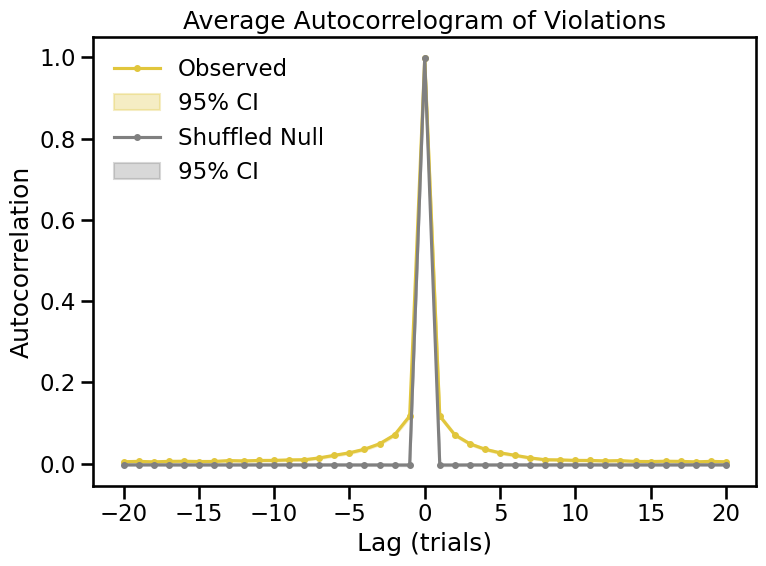

In [112]:

fig, ax = plt.subplots(figsize=(8, 6))

# Plot observed autocorrelation.
plt.plot(lags, obs_mean_ac, label='Observed', color=c.VIOLATION_COLOR, marker="o", markersize=4)
plt.fill_between(lags, ci_lower, ci_upper, alpha=0.3, color=c.VIOLATION_COLOR, label='95% CI')

# Plot the shuffled (null) distribution.
plt.plot(lags, null_mean, label='Shuffled Null', color='gray', marker="o", markersize=4)
plt.fill_between(lags, null_lower, null_upper, alpha=0.3, color='gray', label='95% CI')
# Decoration.
# plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
# ax.set_xlim(-15,15)
plt.title('Average Autocorrelogram of Violations')
plt.legend(frameon=False, loc = "upper left")
plt.tight_layout()


In [ ]:

# 6. (Optional) Compute p-values for each lag.
# Here we re-run the shuffling process to store each shuffle's mean autocorrelogram.
null_distribution = []
for _ in tqdm(range(n_shuffles), desc="Computing p-values via shuffles"):
    df_shuffled = df.copy()
    df_shuffled['violation'] = df_shuffled.groupby('animal_id_session')['violation'] \
                                         .transform(np.random.permutation)
    ac_shuffled = compute_all_autocorrelograms(df_shuffled, max_lag=max_lag)
    if len(ac_shuffled) > 0:
        null_distribution.append(np.mean(ac_shuffled, axis=0))
null_distribution = np.array(null_distribution)
p_values = get_p_values(obs_mean_ac, null_distribution)
print("p-values at each lag:")
for lag, p in zip(lags, p_values):
    print(f"Lag {lag}: p = {p:.3f}")


In [39]:
# Optionally, if you want to control for multiple comparisons across lags,
# you may apply a correction, such as Bonferroni or FDR, to these p-values.
# For instance, for Bonferroni:
corrected_p = np.minimum(p_values * len(p_values), 1.0)
print("Bonferroni-corrected p-values at each lag:")
for lag, p in zip(lags, corrected_p):
    print(f"Lag {lag}: corrected p = {p:.3f}")

Bonferroni-corrected p-values at each lag:
Lag -20: corrected p = 1.000
Lag -19: corrected p = 0.000
Lag -18: corrected p = 1.000
Lag -17: corrected p = 0.000
Lag -16: corrected p = 0.000
Lag -15: corrected p = 0.000
Lag -14: corrected p = 0.000
Lag -13: corrected p = 0.000
Lag -12: corrected p = 0.000
Lag -11: corrected p = 0.000
Lag -10: corrected p = 0.000
Lag -9: corrected p = 0.000
Lag -8: corrected p = 0.000
Lag -7: corrected p = 0.000
Lag -6: corrected p = 0.000
Lag -5: corrected p = 0.000
Lag -4: corrected p = 0.000
Lag -3: corrected p = 0.000
Lag -2: corrected p = 0.000
Lag -1: corrected p = 0.000
Lag 0: corrected p = 1.000
Lag 1: corrected p = 0.000
Lag 2: corrected p = 0.000
Lag 3: corrected p = 0.000
Lag 4: corrected p = 0.000
Lag 5: corrected p = 0.000
Lag 6: corrected p = 0.000
Lag 7: corrected p = 0.000
Lag 8: corrected p = 0.000
Lag 9: corrected p = 0.000
Lag 10: corrected p = 0.000
Lag 11: corrected p = 0.000
Lag 12: corrected p = 0.000
Lag 13: corrected p = 0.000
Lag 

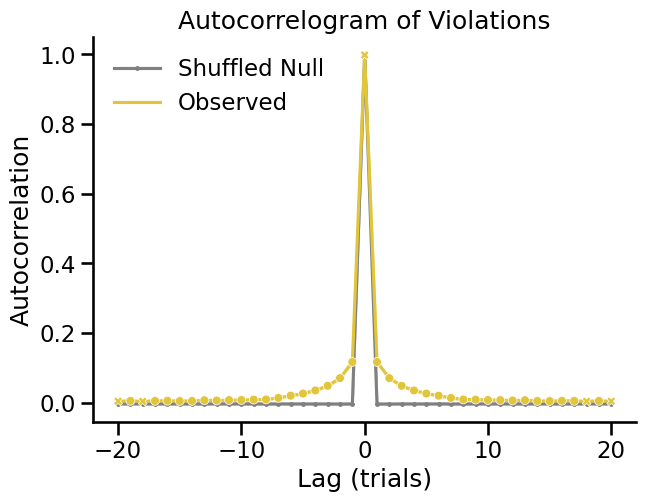

In [156]:
# Assume lags, obs_mean_ac, and corrected_p are already defined.
# Create a significance column based on your alpha threshold.
alpha = 0.05
df_obs = pd.DataFrame({
    'lags': lags,
    'obs_mean_ac': obs_mean_ac,
    'Significance': np.where(corrected_p < alpha, 'Significant', 'Non-significant')
})

fig, ax = plt.subplots(figsize=(7, 5))
# Plot the shuffled (null) distribution.
plt.plot(lags, null_mean, label='Shuffled Null', color='gray', marker='.', markersize=5)
plt.fill_between(lags, null_lower, null_upper, alpha=0.3, color='gray')

# Plot the continuous line for observed autocorrelation.
sns.lineplot(data=df_obs, x="lags", y="obs_mean_ac", ax=ax,
             color=c.VIOLATION_COLOR, linestyle='-', label="Observed")

# Overlay markers with size mapped to significance.
# Here, we use sizes to indicate significance: larger for significant points.
sns.scatterplot(data=df_obs, x="lags", y="obs_mean_ac", hue="Significance",
                palette={'Significant': c.VIOLATION_COLOR, 'Non-significant': c.VIOLATION_COLOR},
                style="Significance",
                markers={'Significant': 'o', 'Non-significant': 'X'},
                legend=False, ax=ax, zorder=10, size=20)

plt.fill_between(lags, ci_lower, ci_upper, alpha=0.3, color=c.VIOLATION_COLOR)



plt.title('Average Autocorrelogram of Violations')
plt.legend(frameon=False, loc = "upper left")
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelogram of Violations')
sns.despine()

plt.savefig("figures/fig3a_violation_autocorrelogram.png", dpi=300, bbox_inches="tight")



# B- Prev Viol Weights


In [195]:
ddf = pd.DataFrame()

ddf["trial"] = np.arange(1,11)
ddf["violation"] = [0,1,0,0,0,1,0,0,0,0]
ddf["prev_violation"] = [0,0,1,0,0,0,1,0,0,0]

filter = ExpFilter(tau=5)
filter.apply_filter_to_session("prev_violation", ddf)
max_val = ddf["prev_violation_exp"].max()
ddf["prev_violation_exp_norm"] = ddf["prev_violation_exp"] / (max_val + 0.12)

ddf

,trial,violation,prev_violation,prev_violation_exp,prev_violation_exp_norm
0,1,0,0,0.000000,0.000000
1,2,1,0,0.000000,0.000000
2,3,0,1,1.000000,0.637215
3,4,0,0,0.818731,0.521708
4,5,0,0,0.670320,0.427138
5,6,1,0,0.548812,0.349711
6,7,0,1,1.449329,0.923534
7,8,0,0,1.186610,0.756126
8,9,0,0,0.971514,0.619063
9,10,0,0,0.795409,0.506846


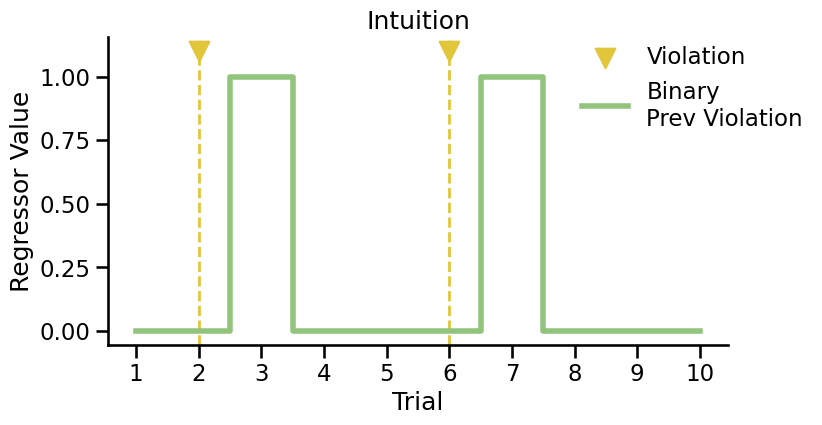

In [247]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation"], drawstyle='steps-mid', label="Binary\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_COLOR, linewidth=4)

ax.legend(bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Intuition",
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()

plt.savefig("figures/fig3b_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

In [157]:
mvpv = ModelVisualizer(load_experiment(prev_viol_exp))
XMIN=-2.1
XMAX=2.1

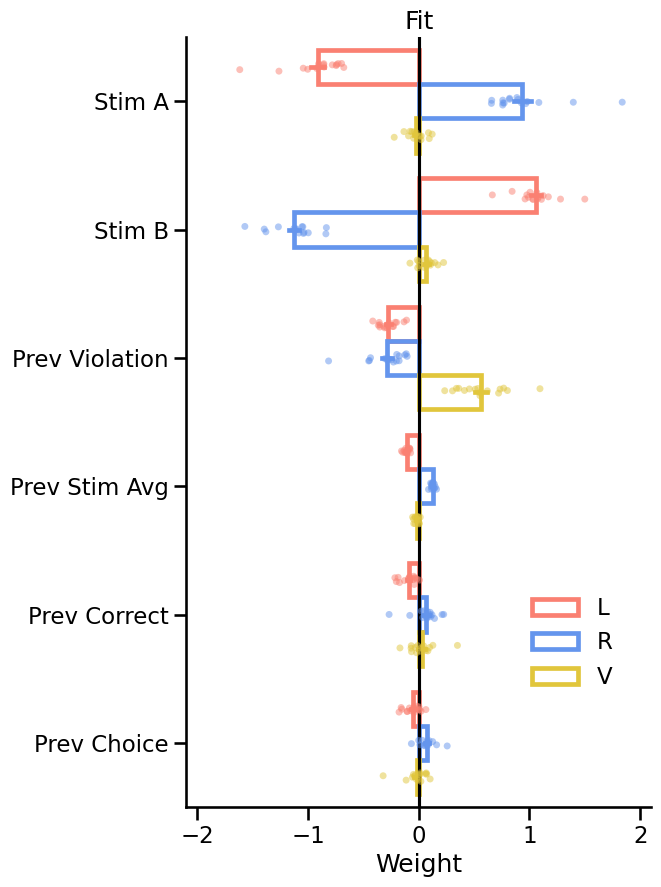

In [250]:
fig, ax = plt.subplots(figsize=(6, 10)) 

mvpv.plot_weights_summary(ax=ax,orientation="h", plot_bias = False, title="Fit", plot_individuals=True, seed=19, palette=c.MULTI_CHOICE_PAL)

ax.legend(bbox_to_anchor=(0.7, 0.3), frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Prev Violation", 
    "Prev Stim Avg", 
    "Prev Correct", 
    "Prev Choice"
]

# set y labels
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# set x label
ax.set_xlabel("Weight")
ax.set_xlim(XMIN, XMAX)

plt.savefig("figures/fig3b_prev_viol_weights.png", dpi=300, bbox_inches="tight")

# C/D Filt Prev Viol Weights & Tau


In [251]:
mvfpv = ModelVisualizer(load_experiment(filt_prev_viol_exp))



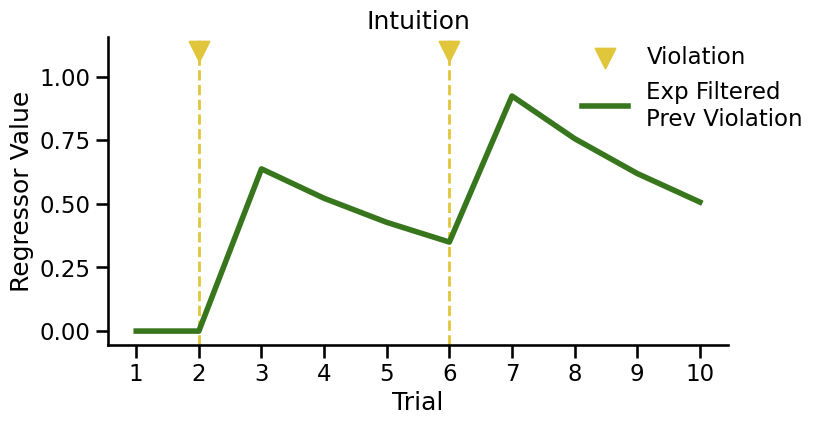

In [254]:
fig, ax = plt.subplots(figsize=(8, 4)) 

vddf = ddf.query("violation == 1")

ax.scatter(vddf["trial"], (vddf["violation"] + 0.1), color=c.VIOLATION_COLOR, marker="v", label="Violation", s=200)
for trial in vddf["trial"]:
    ax.axvline(x=trial, ymax=1.0, color=c.VIOLATION_COLOR, linestyle='--', linewidth=2)

sns.lineplot(x=ddf["trial"], y=ddf["prev_violation_exp_norm"], label="Exp Filtered\nPrev Violation", ax=ax, color=c.PREV_VIOLATION_FILTER_COLOR, linewidth=4)

ax.legend(bbox_to_anchor=(.75, 1), loc='upper left', borderaxespad=0., frameon=False)

ax.set(
    ylabel="Regressor Value",
    xlabel="Trial",
    title="Intuition"
)

ax.set_xticks(np.arange(1, 11))  # Set x ticks from 1 to 10

sns.despine()
plt.savefig("figures/fig3d_filt_prev_viol_weights_intuition.png", dpi=300, bbox_inches="tight")

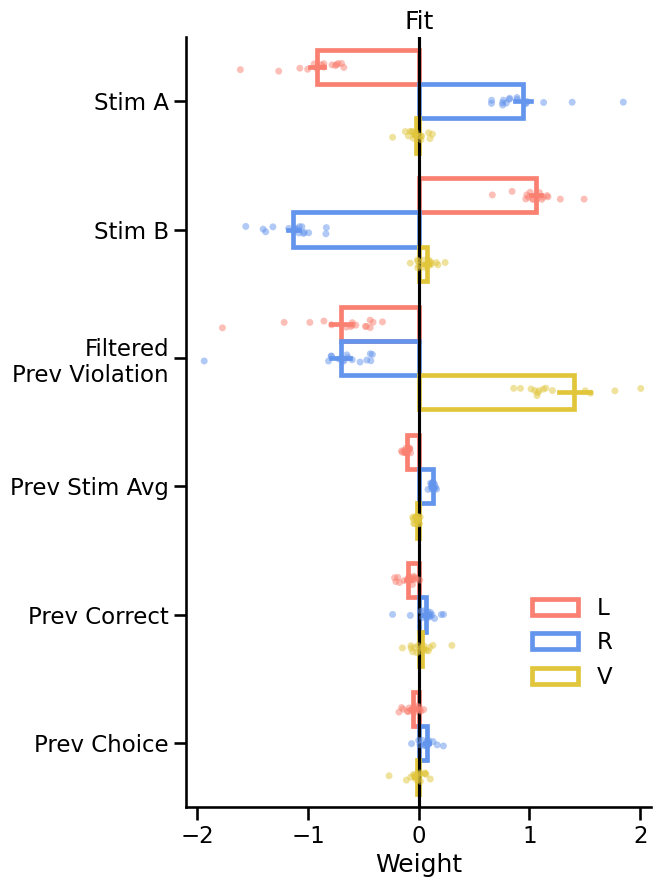

In [253]:
fig, ax = plt.subplots(figsize=(6, 10)) 

mvfpv.plot_weights_summary(ax=ax,orientation="h", plot_bias = False, title="Fit", plot_individuals=True, seed=19, palette=c.MULTI_CHOICE_PAL)

ax.legend(bbox_to_anchor=(0.7, 0.3), frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Filtered\nPrev Violation", 
    "Prev Stim Avg", 
    "Prev Correct", 
    "Prev Choice"
]

# set y labels
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# set x label
ax.set_xlabel("Weight")
ax.set_xlim(XMIN, XMAX)

plt.savefig("figures/fig3d_filt_prev_viol_weights.png", dpi=300, bbox_inches="tight")


In [52]:
taus_df = pd.read_csv("/Users/jessbreda/Desktop/github/violations-multinomial/data/processed/tau_sweeps/taus_df.csv")

taus_df = taus_df.query("animal_id in @ANIMAL_IDS")

In [53]:
taus_df

,animal_id,prev_violation_tau,prev_tns_viol_combo_tau,prev_tns_tau
0,W051,2.0,2.0,2.00
1,W060,2.0,2.0,1.00
2,W065,2.0,2.0,1.00
3,W066,25.0,20.0,2.00
4,W068,40.0,1.0,1.00
5,W072,1.0,1.0,1.00
6,W073,2.0,2.0,1.00
7,W074,3.0,3.0,1.00
8,W075,15.0,15.0,1.00
9,W078,1.0,1.0,0.51


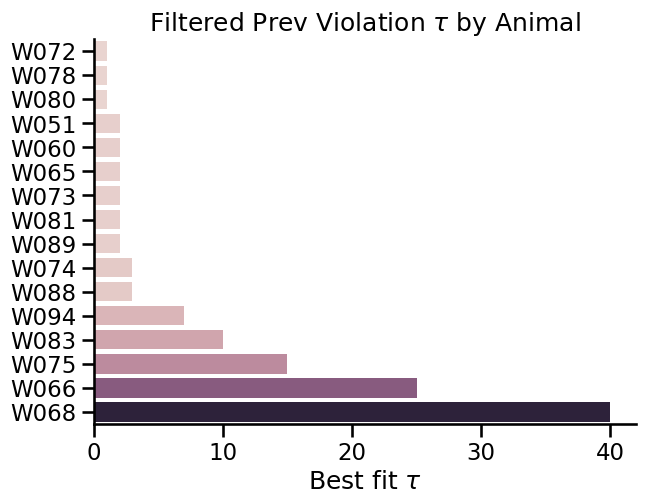

In [166]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(taus_df.sort_values("prev_violation_tau"), x="prev_violation_tau", y="animal_id", ax=ax, hue="prev_violation_tau" )

ax.legend().remove()

ax.set(
    xlabel = r"Best fit $\tau$",
    ylabel=""
)
sns.despine()
ax.set_title(r"Filtered Prev Violation $\tau$ by Animal")

plt.savefig("figures/fig3c_filt_prev_viol_taus.png", dpi=300, bbox_inches="tight")


In [256]:
taus_df.prev_violation_tau.median()

2.0

# E- Model Comparison


In [3]:
mvc = ModelVisualizerCompare(load_experiment(compare_exp))

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_filtered",
]
LABELS = [
    "Base\nMulti-class",
    "+ Binary \nPrev Violation",
    "+ Filtered \nPrev Violation",
]

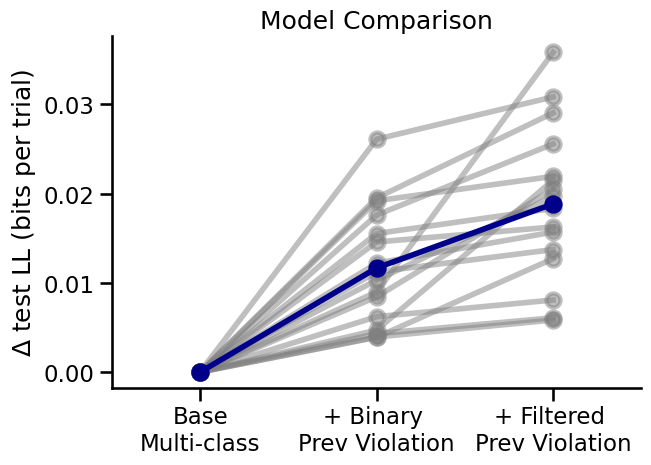

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
ax.legend().remove()
ax.set(xlabel="", title="Model Comparison")

# save fig
plt.tight_layout()
plt.savefig("figures/fig3e_compare_prev_viol.png", dpi=300, bbox_inches="tight")

In [267]:
bpt.head()

,animal_id,model_name,nll,sigma,model_type,n_train_trials,n_test_trials,log_like,bits_per_trial,bits_per_trial_relative_to_base,likelihood_ratio_relative_to_base
0,W051,base,15379.882408,0.13,multi,79769,19154,-15379.882408,0.272492,0.000000,1.000000e+00
1,W051,null,18997.630283,NaN,multi,79769,19154,-18997.630283,-1.430917,-1.703409,0.000000e+00
2,W051,prev_viol_binary,15297.451365,16.00,multi,79769,19154,-15297.451365,0.278701,0.006209,6.300094e+35
3,W051,prev_viol_filtered,15272.679818,16.00,multi,79769,19154,-15272.679818,0.280566,0.008075,3.609886e+46
4,W060,base,12034.287671,16.00,multi,65921,15885,-12034.287671,0.330444,0.000000,1.000000e+00


In [271]:
bpt = mvc.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "
                                                               std"])

,mean,std
model_name,,
base,0.000000,0.000000
null,-1.775654,0.071471
prev_viol_binary,0.011669,0.006623
prev_viol_filtered,0.018852,0.008682


## Base vs Binary


In [18]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:896: RuntimeWarning: overflow encountered in scalar power
  """
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:900: RuntimeWarning: overflow encountered in scalar power
  params


{'overall_ratio': inf, 'log10_overall_ratio': 1297.9930496690224}

> Pooling across animals, the test data are $10^{1298}$ times more likely under the new model than under the base model.


In [19]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

{'geometric_mean_ratio': 1.332188266828118e+81,
 'log10_geometric_mean_ratio': 81.1245656043139}

> On average, each animal's test data is $1.33 * 10^{81}$ times more likely under the previous violation binary model


## Base vs Filtered


In [17]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:896: RuntimeWarning: overflow encountered in scalar power
  """
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:900: RuntimeWarning: overflow encountered in scalar power
  params


{'overall_ratio': inf, 'log10_overall_ratio': 2311.621968203722}

> Pooling across animals, the test data are $10^{2312}$ times more likely under the new model than under the base model.


In [20]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

{'geometric_mean_ratio': 2.994835777437509e+144,
 'log10_geometric_mean_ratio': 144.47637301273264}

> On average, each animal's test data is $3.0 * 10^{144}$ times more likely under the previous violation filtered model
